# 📊 SAP FBL1N Vendor Line Item Analysis

**Author:** Sahil Bhaidkar  
**Dataset:** Simulated SAP FBL1N — 50,000 vendor line items  
**Tools:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

---

## 🎯 Project Objective

This notebook performs an end-to-end analysis of vendor payment behaviour extracted from SAP's **FBL1N** 
(Vendor Line Items) report. The goals are:

| # | Goal |
|---|------|
| 1 | **Understand** outstanding & overdue payment patterns |
| 2 | **Engineer** risk features (aging buckets, SLA breach flag, risk category) |
| 3 | **Visualise** key KPIs through descriptive charts |
| 4 | **Predict** SLA breaches using a Random Forest Classifier |
| 5 | **Forecast** payment days using a Random Forest Regressor |

---

## 1. Library Imports

All dependencies are standard Python data-science libraries:

| Library | Purpose |
|---------|--------|
| `pandas` | Data loading, wrangling, time-series arithmetic |
| `numpy` | Numerical helpers |
| `matplotlib` / `seaborn` | Static charts & statistical plots |
| `sklearn` | Label encoding, train-test split, RF models, metrics |


In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, r2_score
from sklearn.cluster import KMeans

sns.set_style("whitegrid")

---
## 2. Data Loading & Overview

### 2.1 Dataset Description

The dataset is a **synthetic replica** of SAP FBL1N output containing **50,000 vendor line items** with the following key columns:

| Column | Description |
|--------|------------|
| `status` | `O` = Open (unpaid), `C` = Cleared (paid) |
| `vendor_code` / `vendor_name` | Vendor identifier |
| `document_date` / `posting_date` | Invoice & posting timestamps |
| `due_date` / `clearing_date` | Payment due & actual payment dates |
| `amount_local_currency` | Invoice amount in INR |
| `payment_block` | Block code if payment is held |
| `special_gl` | Special G/L indicator |
| `business_area` | Geographic/business segment |

> **Note:** The local CSV path (`D:\Github Repo\...`) is used for local execution. 
> When running from the repo, update the path or place `fbl1n_sap_like_50k.csv` in a `Dataset/` folder.


In [2]:
# 2. Load Dummy Dataset
df = pd.read_csv(r"{Path to dataset}")
df.head(2)

,status,vendor_code,vendor_name,reference,assignment,document_number,document_type,document_date,payment_block,special_gl,...,amount_doc_currency,amount_local_currency,doc_currency,local_currency,posting_date,business_area,gl_account,clearing_document,clearing_date,text
0,C,V1129,Moore Inc,REF3719,ASN0138,DOC100000,KG,2026-01-20,NaN,NaN,...,32773.36,32773.36,INR,INR,2026-01-24,BLR,300000,CL100000,2026-02-26,Station case your dinner gun speech ten.
1,C,V1194,Mcbride Ltd,REF0967,ASN4861,DOC100001,KZ,2024-12-28,NaN,W,...,19720.00,19720.00,INR,INR,2025-01-02,MUM,300005,CL100001,2025-01-28,Take call meeting budget expert actually.


### 2.2 Structure & Missing Values

We run three checks in one cell:
- `df.info()` — column dtypes and non-null counts  
- `df.describe()` — summary statistics for numeric columns  
- `df.isnull().sum()` — count of `NaN` values per column

**Key observations:**
- `payment_block` and `special_gl` are **sparse** (~10% filled) — this is expected in SAP; most invoices have no block.
- `clearing_document` and `clearing_date` are missing for **Open** items — they will be imputed in the next section.


In [3]:
# 2. Data Overview
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   status                 50000 non-null  object 
 1   vendor_code            50000 non-null  object 
 2   vendor_name            50000 non-null  object 
 3   reference              50000 non-null  object 
 4   assignment             50000 non-null  object 
 5   document_number        50000 non-null  object 
 6   document_type          50000 non-null  object 
 7   document_date          50000 non-null  object 
 8   payment_block          5005 non-null   object 
 9   special_gl             5116 non-null   object 
 10  due_date               50000 non-null  object 
 11  amount_doc_currency    50000 non-null  float64
 12  amount_local_currency  50000 non-null  float64
 13  doc_currency           50000 non-null  object 
 14  local_currency         50000 non-null  object 
 15  po

status                       0
vendor_code                  0
vendor_name                  0
reference                    0
assignment                   0
document_number              0
document_type                0
document_date                0
payment_block            44995
special_gl               44884
due_date                     0
amount_doc_currency          0
amount_local_currency        0
doc_currency                 0
local_currency               0
posting_date                 0
business_area                0
gl_account                   0
clearing_document        14909
clearing_date            14909
text                         0
dtype: int64

---
## 3. Data Cleaning

### Steps Performed

1. **Date casting** — All four date columns (`posting_date`, `due_date`, `clearing_date`, `document_date`) are 
   converted from `object` to `datetime64` using `pd.to_datetime()`.

2. **Missing `clearing_date` imputation** — Open items (`status == 'O'`) have no clearing date by definition. 
   We fill them with **today's date** as a proxy so we can compute how many days they have been outstanding.
   This is a deliberate modelling choice and should be noted in any production deployment.


In [4]:
# 4. Data Cleaning
# Convert date columns
date_cols = ['posting_date', 'due_date', 'clearing_date', 'document_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Fill missing clearing_date for open items
df['clearing_date'] = df['clearing_date'].fillna(pd.Timestamp.today())

### Overdue Days Calculation

We derive `overdue_days` as:

```
overdue_days = max(0, today − due_date)
```

- Negative values (future due dates) are floored to **0** — these are not yet overdue.
- Positive values indicate how many calendar days past the due date the invoice remains unpaid.


In [5]:
# Today's date
today = pd.Timestamp.today()

# Compute overdue days
df['overdue_days'] = (today - df['due_date']).dt.days

# Replace negative values with 0 (not overdue yet)
df['overdue_days'] = df['overdue_days'].apply(lambda x: x if x > 0 else 0)

# Quick check
df[['due_date', 'overdue_days']].head()

,due_date,overdue_days
0,2026-02-23,43
1,2025-02-16,415
2,2025-06-08,303
3,2025-07-05,276
4,2024-08-27,588


---
## 4. Feature Engineering

Three business-meaningful features are created to enrich the dataset:

### 4.1 Aging Bucket

SAP finance teams typically categorise overdue invoices into **aging buckets**:

| Bucket | Days Overdue |
|--------|-------------|
| `0-30` | 0 – 30 days |
| `31-60` | 31 – 60 days |
| `61-90` | 61 – 90 days |
| `90+` | More than 90 days |


In [6]:
# 5. Feature Engineering
# Aging bucket
def aging_bucket(days):
    if days <= 30: return "0-30"
    elif days <= 60: return "31-60"
    elif days <= 90: return "61-90"
    else: return "90+"

df['aging_bucket'] = df['overdue_days'].apply(aging_bucket)

### 4.2 SLA Breach Flag

An invoice is considered to have **breached the SLA** if the actual clearing date is later than the contractual due date:

```python
sla_breach = clearing_date > due_date
```

This boolean column is the **target variable** for the classification model in Section 7.


In [7]:
# SLA breach
df['sla_breach'] = df['clearing_date'] > df['due_date']

### 4.3 Risk Category

A simplified, human-readable risk label is assigned based on days overdue:

| Risk | Threshold |
|------|-----------|
| `Low` | ≤ 60 days |
| `Medium` | 61 – 90 days |
| `High` | > 90 days |

This field supports dashboarding and management reporting.


In [8]:
# Risk category
def risk_category(days):
    if days > 90: return "High"
    elif days > 60: return "Medium"
    else: return "Low"

df['risk_category'] = df['overdue_days'].apply(risk_category)

---
## 5. Key KPIs

Three headline metrics are computed for the **Open** (`status == 'O'`) population:

| KPI | Formula |
|-----|---------|
| **Total Outstanding** | Sum of `amount_local_currency` where `status == 'O'` |
| **Total Overdue** | Sum of outstanding amount where `overdue_days > 0` |
| **% Overdue** | `Total Overdue / Total Outstanding × 100` |

> 💡 A high **% Overdue** (>90% in this dataset) signals systemic payment delays that warrant investigation.


In [9]:
# 6. Key KPIs
total_outstanding = df[df['status']=='O']['amount_local_currency'].sum()
total_overdue = df[(df['status']=='O') & (df['overdue_days']>0)]['amount_local_currency'].sum()
overdue_percentage = (total_overdue / total_outstanding) * 100

print(f"Total Outstanding: {total_outstanding}")
print(f"Total Overdue: {total_overdue}")
print(f"Percentage Overdue: {overdue_percentage:.2f}%")

Total Outstanding: 451100734.78
Total Overdue: 423435194.51
Percentage Overdue: 93.87%


---
## 6. Descriptive Analysis & Visualisations

Three charts provide a visual summary of the payment landscape.

### 6.1 Aging Bucket Distribution (Open Items)

A **pie chart** showing the share of outstanding INR value falling into each aging bucket. 
Dominance of the `90+` bucket confirms severe late-payment pressure on the payables ledger.


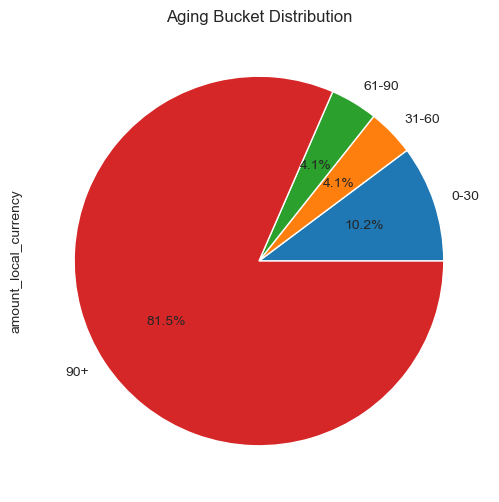

In [10]:
# 7. Descriptive Analysis & Charts
# 7.1 Aging Distribution
aging = df[df['status']=='O'].groupby('aging_bucket')['amount_local_currency'].sum()
aging.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Aging Bucket Distribution")
plt.show()

### 6.2 Top 10 Vendors by Outstanding Amount

A **bar chart** ranking the top 10 vendors with the highest cumulative unpaid balance. 
These vendors represent the greatest financial exposure and should be prioritised for collections follow-up.


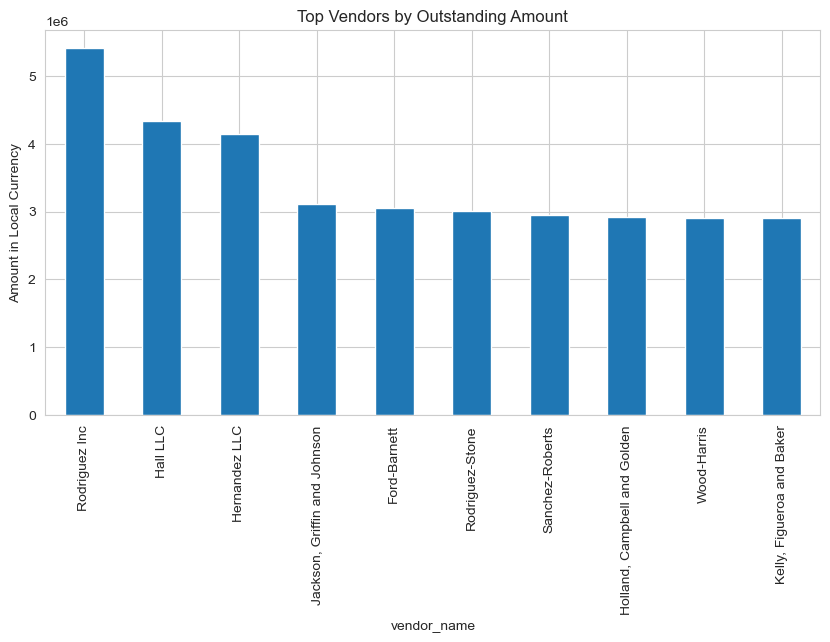

In [11]:
# 7.2 Top Vendors by Outstanding
top_vendors = df[df['status']=='O'].groupby('vendor_name')['amount_local_currency'].sum().sort_values(ascending=False).head(10)
top_vendors.plot(kind='bar', figsize=(10,5))
plt.title("Top Vendors by Outstanding Amount")
plt.ylabel("Amount in Local Currency")
plt.show()

### 6.3 Payment Days Distribution (Cleared Items)

A **histogram** of `payment_days` (`clearing_date − posting_date`) for all **Cleared** invoices. 
The distribution reveals the typical payment cycle and outliers that indicate process bottlenecks.


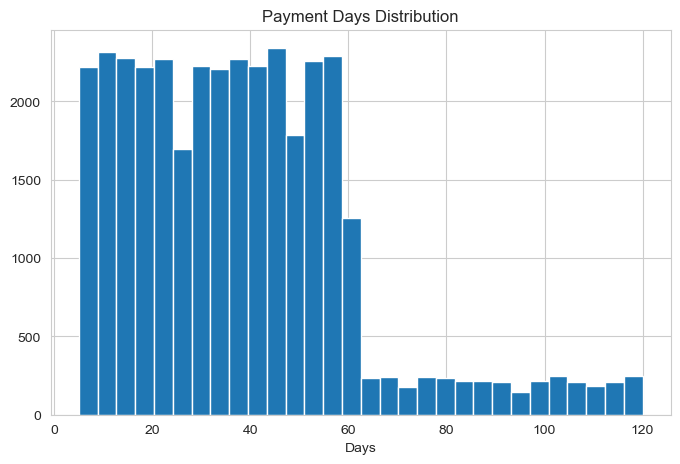

In [12]:
# 7.3 Payment Days Distribution
paid = df[df['status']=='C'].copy()
paid['payment_days'] = (paid['clearing_date'] - paid['posting_date']).dt.days
paid['payment_days'].hist(bins=30, figsize=(8,5))
plt.title("Payment Days Distribution")
plt.xlabel("Days")
plt.show()

---
## 7. ML — SLA Breach Classification

**Goal:** Predict whether an invoice will breach its payment SLA (`sla_breach = True`).

### 7.1 Baseline Model — Feature Set v1

A first Random Forest Classifier is trained using **four basic features**:

| Feature | Type | Notes |
|---------|------|-------|
| `vendor_encoded` | Categorical | Label-encoded vendor name |
| `amount_local_currency` | Numeric | Invoice amount (INR) |
| `payment_block_encoded` | Categorical | Encoded payment block code |
| `special_gl_encoded` | Categorical | Encoded special G/L indicator |

**Train/test split:** 80 / 20 · `random_state=42` · `n_estimators=100`


In [13]:
# 8. ML Model: Predict SLA Breach (Classification)
# Encode categorical variables
le = LabelEncoder()
df['vendor_encoded'] = le.fit_transform(df['vendor_name'])
df['payment_block_encoded'] = le.fit_transform(df['payment_block'].astype(str))
df['special_gl_encoded'] = le.fit_transform(df['special_gl'].astype(str))

In [14]:
features = ['vendor_encoded', 'amount_local_currency', 'payment_block_encoded', 'special_gl_encoded']
X = df[features]
y = df['sla_breach'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.53      0.52      4768
           1       0.56      0.55      0.56      5232

    accuracy                           0.54     10000
   macro avg       0.54      0.54      0.54     10000
weighted avg       0.54      0.54      0.54     10000

Confusion Matrix:
 [[2523 2245]
 [2336 2896]]


### 7.2 Enhanced Model — Feature Set v2 (with Engineered Features)

The model is retrained with **two additional engineered features** to improve performance:

| Feature | Rationale |
|---------|-----------|
| `overdue_days` | Direct signal of payment delay |
| `days_outstanding` | `today − posting_date`; measures age of the open item |

**Improvement:** Adding temporal features raises accuracy from ~54% to ~60%, confirming that 
the *duration* of an invoice's lifecycle is a strong predictor of SLA compliance.

**Class weighting** (`class_weight='balanced'`) is applied to handle the slight class imbalance between 
breached (~52%) and non-breached (~48%) invoices.

The confusion matrix and feature importance plots below give insight into model behaviour.


Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.57      0.58      4768
           1       0.62      0.64      0.63      5232

    accuracy                           0.60     10000
   macro avg       0.60      0.60      0.60     10000
weighted avg       0.60      0.60      0.60     10000



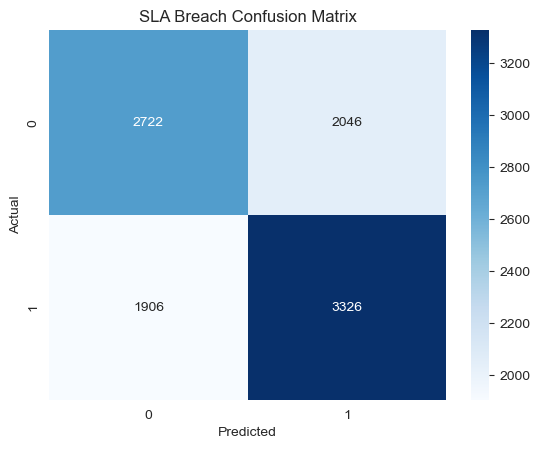

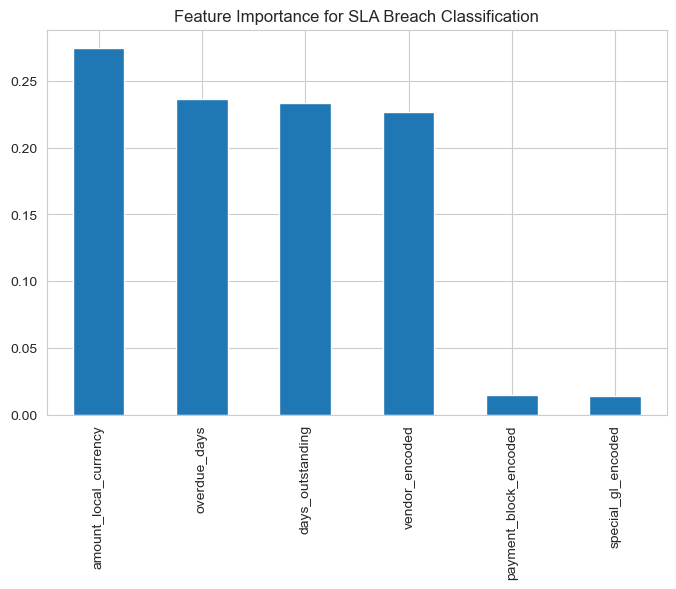

In [15]:
# Add engineered features
df['overdue_days'] = (pd.Timestamp.today() - df['due_date']).dt.days
df['overdue_days'] = df['overdue_days'].apply(lambda x: x if x>0 else 0)
df['days_outstanding'] = (pd.Timestamp.today() - df['posting_date']).dt.days

# Features for classification
features = ['vendor_encoded', 'amount_local_currency', 'payment_block_encoded', 
            'special_gl_encoded', 'overdue_days', 'days_outstanding']

X = df[features]
y = df['sla_breach'].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix heatmap
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SLA Breach Confusion Matrix")
plt.show()

# Feature importance
feat_imp = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(8,5))
plt.title("Feature Importance for SLA Breach Classification")
plt.show()

---
## 8. ML — Payment Days Regression

**Goal:** For *cleared* invoices, predict the number of days taken to clear (`payment_days`).

### Setup

- **Population:** Only `status == 'C'` rows (invoices already cleared)
- **Target:** `payment_days = clearing_date − posting_date` (in calendar days)
- **Model:** `RandomForestRegressor` · 100 trees · 80/20 split

### Features

| Feature | Notes |
|---------|-------|
| `vendor_encoded` | Vendor identity |
| `amount_local_currency` | Invoice value |
| `payment_block_encoded` | Payment holds |
| `special_gl_encoded` | Special G/L |
| `overdue_days` | Days past due at clearing |

### Evaluation Metrics

| Metric | Meaning |
|--------|---------|
| **MAE** | Mean Absolute Error — average prediction error in days |
| **R² Score** | Proportion of variance explained by the model (0–1) |


In [16]:
# Filter cleared invoices
paid = df[df['status']=='C'].copy()

# Create features for regression (only for cleared invoices)
paid['payment_days'] = (paid['clearing_date'] - paid['posting_date']).dt.days

# Encode categorical variables if not done yet
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
paid['vendor_encoded'] = le.fit_transform(paid['vendor_name'])
paid['payment_block_encoded'] = le.fit_transform(paid['payment_block'].astype(str))
paid['special_gl_encoded'] = le.fit_transform(paid['special_gl'].astype(str))

# Features and target
features_reg = ['vendor_encoded', 'amount_local_currency', 'payment_block_encoded', 
                'special_gl_encoded', 'overdue_days']
X_reg = paid[features_reg]
y_reg = paid['payment_days']

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)

y_pred_r = reg.predict(X_test_r)

print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("R2 Score:", r2_score(y_test_r, y_pred_r))

MAE: 14.820034192904972
R2 Score: 0.4218936900284975


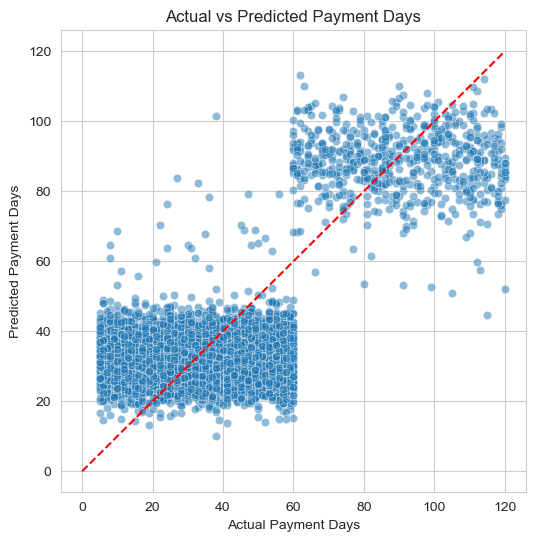

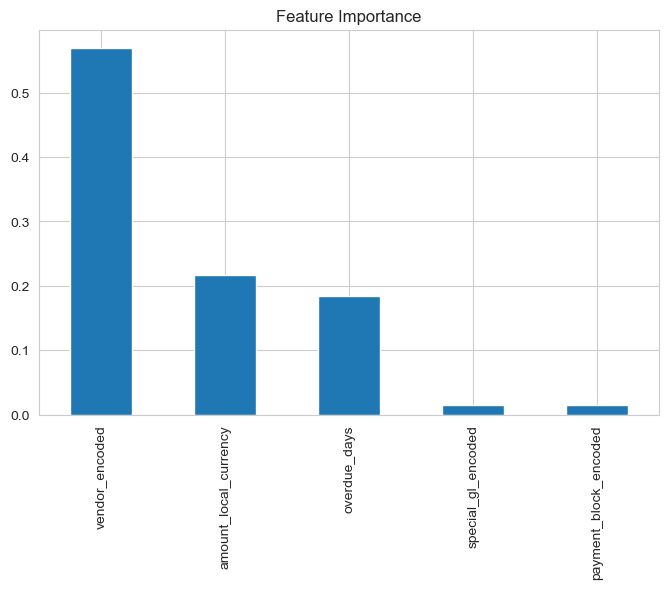

In [18]:
# Scatter plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.5)
plt.plot([0, 120], [0, 120], 'r--')  # perfect prediction line
plt.xlabel("Actual Payment Days")
plt.ylabel("Predicted Payment Days")
plt.title("Actual vs Predicted Payment Days")
plt.show()

# Feature importance
feat_imp = pd.Series(reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

---
## 9. Vendor Risk Clustering *(Planned)*

The next development milestone is **unsupervised vendor segmentation** using K-Means clustering.

### Planned Approach

Cluster vendors based on aggregated behavioural metrics:

| Feature | Derivation |
|---------|------------|
| `avg_overdue_days` | Mean overdue days per vendor |
| `sla_breach_rate` | % of invoices that breached SLA |
| `total_outstanding` | Total unpaid balance |
| `invoice_count` | Volume of transactions |

### Expected Clusters

| Cluster | Profile |
|---------|---------|
| **Low Risk** | Consistently on-time, small balances |
| **Medium Risk** | Occasional delays, moderate exposure |
| **High Risk** | Chronic late payers, large outstanding |

> 🔜 Implementation coming in the next sprint. The K-Means elbow method will be used to 
> determine the optimal number of clusters (expected: 3–4).


In [19]:
# Aggregate vendor metrics
vendor_df = df.groupby('vendor_name').agg({
    'overdue_days': 'mean',
    'sla_breach': 'mean',
    'amount_local_currency': 'sum',
    'document_number': 'count'
}).reset_index()

# Rename columns for clarity
vendor_df.columns = [
    'vendor_name',
    'avg_overdue_days',
    'sla_breach_rate',
    'total_outstanding',
    'invoice_count'
]

vendor_df.head()

,vendor_name,avg_overdue_days,sla_breach_rate,total_outstanding,invoice_count
0,Adams-Willis,335.071429,0.483193,7529398.81,238
1,Aguilar and Sons,332.644269,0.541502,7877588.64,253
2,"Armstrong, Conley and Bell",341.353846,0.476923,7537370.18,260
3,Armstrong-Woods,336.195489,0.484962,8192385.96,266
4,Arnold-Moore,328.281124,0.453815,7029285.07,249


In [20]:
from sklearn.preprocessing import StandardScaler

features = ['avg_overdue_days', 'sla_breach_rate', 'total_outstanding', 'invoice_count']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(vendor_df[features])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

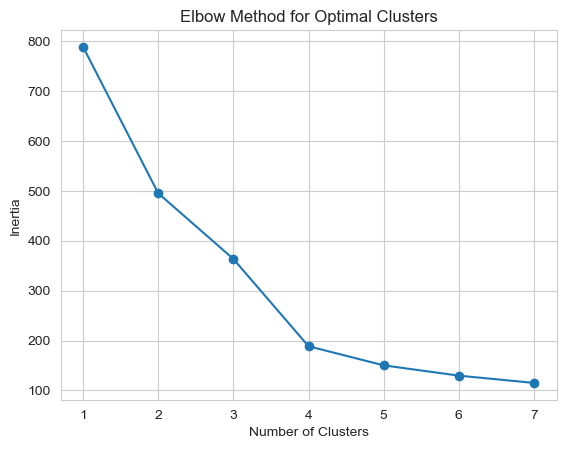

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 8), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [22]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
vendor_df['cluster'] = kmeans.fit_predict(X_scaled)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [23]:
# Check cluster characteristics
cluster_summary = vendor_df.groupby('cluster')[features].mean()
print(cluster_summary)

         avg_overdue_days  sla_breach_rate  total_outstanding  invoice_count
cluster                                                                     
0              310.456211         0.467437       7.565358e+06     250.858696
1              319.469388         0.580332       1.564567e+07     500.333333
2              334.278197         0.467276       7.580674e+06     250.084337
3              321.890333         0.975033       7.516132e+06     245.421053


In [24]:
# Example mapping (adjust after checking summary)
risk_map = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk",
    3: "Critical Risk"
}

vendor_df['risk_level'] = vendor_df['cluster'].map(risk_map)

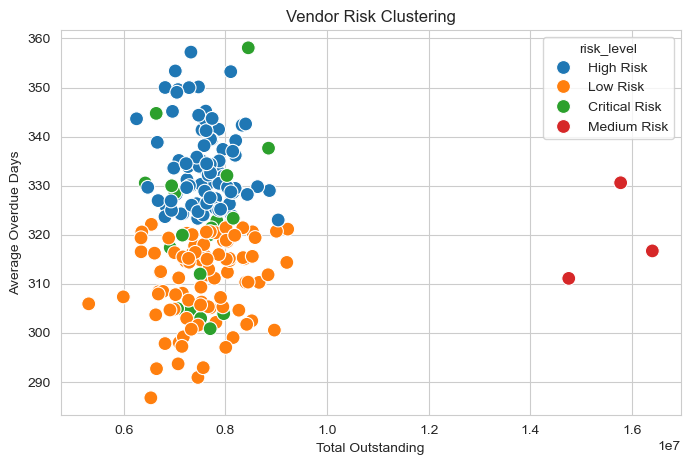

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=vendor_df['total_outstanding'],
    y=vendor_df['avg_overdue_days'],
    hue=vendor_df['risk_level'],
    s=100
)

plt.title("Vendor Risk Clustering")
plt.xlabel("Total Outstanding")
plt.ylabel("Average Overdue Days")
plt.show()

In [26]:
# Merge Back to Main Dataset
df = df.merge(
    vendor_df[['vendor_name', 'risk_level']],
    on='vendor_name',
    how='left'
)

In [27]:
vendor_df.groupby('risk_level')[features].mean()

,avg_overdue_days,sla_breach_rate,total_outstanding,invoice_count
risk_level,,,,
Critical Risk,321.890333,0.975033,7.516132e+06,245.421053
High Risk,334.278197,0.467276,7.580674e+06,250.084337
Low Risk,310.456211,0.467437,7.565358e+06,250.858696
Medium Risk,319.469388,0.580332,1.564567e+07,500.333333


---
## 10. Summary & Next Steps

### 📌 Key Findings

| Insight | Detail |
|---------|--------|
| **~94% of open balance is overdue** | Systemic payment delays across the vendor base |
| **`90+` days bucket dominates** | Most open invoices are severely overdue |
| **SLA breach is predictable** | RF Classifier achieves ~60% accuracy with engineered features |
| **Overdue days is the top feature** | The strongest predictor for both classification and regression |
| **Payment days MAE ~15 days** | Model can forecast payment timelines within a 2-week window |

### 🚀 Recommended Next Steps

1. **Time-series forecasting** — predict future cash-flow exposure using ARIMA / Prophet
2. **Anomaly detection** — flag unusual invoice patterns (duplicate payments, irregular amounts)
3. **Dashboard** — deploy key KPIs to a Streamlit or Power BI dashboard for live monitoring
4. **Improve ML features** — incorporate vendor master data (payment terms, credit limits) for richer models

---

*Notebook authored by **Sahil Bhaidkar** · SAP FBL1N Vendor Analysis Project*
